# Data Preprocessing and Exploratory Data Analysis

## Set Up and Libraries

In [2]:
import os
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Switch Directories for Google Colab
if os.getcwd() == '/content':
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir("/content/drive/Othercomputers/My MacBook Pro/CreditCardFraudDetection/notebooks")

# Current working directory
print(os.getcwd())

/Users/nazarii.dubelovskyi/PycharmProjects/CreditCardFraudDetection/notebooks


## Data Preprocessing

### Load Data

In [4]:
# Read the Data
train_transaction = pd.read_csv("../data/train_transaction.csv")
train_identity = pd.read_csv("../data/train_identity.csv")
train_identity["identity"] = 1

# Merge the training data and Drop unnecessary identification column
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left').drop(columns=["TransactionID"])
df["identity"] = df["identity"].fillna(0)

In [5]:
# Check the main dataset for balance
# Each column value is either 0 (no fraud, negative) or 1 (fraud, positive)
categories = df["isFraud"]
fraud = categories.sum()
no_fraud = len(categories) - fraud
print(fraud, no_fraud)
print("{:.1f}% of transactions is classified as fraud".format((fraud/len(categories))*100)) # Imbalanced

# Compare whether "identity" features can be omitted in case of too many missing values
df_i = pd.merge(train_transaction, train_identity, on='TransactionID', how='right').drop(columns=["TransactionID"])
categories_i = df_i["isFraud"]
fraud_i = categories_i.sum()
no_fraud_i = len(categories_i) - fraud_i
print(fraud_i, no_fraud_i)
print("{:.1f}% of transactions is classified as fraud".format((fraud_i/len(categories_i))*100))
# The identity dataset, even though smaller, has a twice larger percentage of transactions identified as fraud
# Need to be careful removing the identity-contributed features that might have too many missing values

20663 569877
3.5% of transactions is classified as fraud
11318 132915
7.8% of transactions is classified as fraud


In [6]:
# Split into X and y
X = df.drop(columns="isFraud")
y = df["isFraud"]

# X-y train-test split
# Train: X - features, y - target (trained on)
# Test (evaluation): X - features, y - target (checked against)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=0)

### Transformations on the Training DataFrame

#### Remove Columns with too many Missing Values

In [7]:
# Missing Values: Drop at cutoffs first
# For the non-identity categories, apply normal cutoff at ~40%
# Non-identity columns are the first 394 columns of df
ni_cols = X_train.columns[:394]
ni_cols_keep = X_train[ni_cols].loc[:, X_train[ni_cols].isnull().mean() <= 0.4]

# For the identity categories, cutoff at ~80% since identity has high influence
i_cols = X_train.columns[394:]
i_cols_keep = X_train[i_cols].loc[:, X_train[i_cols].isnull().mean() <= 0.8]

# Save the name of the dropped columns
ni_cols_dropped = ni_cols.difference(ni_cols_keep.columns)
i_cols_dropped = i_cols.difference(i_cols_keep.columns)
cutoff_dropped_cols = ni_cols_dropped.union(i_cols_dropped)

# Concatenate the dataframe
X_train = pd.concat([ni_cols_keep, i_cols_keep], axis=1)

#### Transform Qualitative Predictors into Quantitative

In [8]:
# Categorical features
# Apply One-Hot Encoder on Object Dataset Categories
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Select object columns
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
X_train[cat_cols] = X_train[cat_cols].fillna('missing')

# Store the top 10 most occurring categories in each column, later creating a separate column for each
# For the less occuring categories, assign "Other" category to that distinct column value, later grouping under a single column
encoded_top_10_map = {}
for col in cat_cols:
    encoded_top_10_map[col] = X_train[col].value_counts().index[:10].tolist()
    X_train[col] = X_train[col].where(X_train[col].isin(encoded_top_10_map[col]), 'other')

# Encode object columns
encoded_array = encoder.fit_transform(X_train[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=X_train.index)

# Count unique categorical values after selecting up to the top 10 most occurring ones
print("Uniqueness after top-10 + 'other':")
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

# Replace object columns with encoded columns
X_train = pd.concat([X_train.drop(columns=cat_cols), encoded_df], axis=1)

Uniqueness after top-10 + 'other':
ProductCD: 5 unique values
card4: 5 unique values
card6: 5 unique values
P_emaildomain: 11 unique values
M6: 3 unique values
id_12: 3 unique values
id_15: 4 unique values
id_16: 3 unique values
id_28: 3 unique values
id_29: 3 unique values
id_31: 11 unique values
id_35: 3 unique values
id_36: 3 unique values
id_37: 3 unique values
id_38: 3 unique values
DeviceType: 3 unique values
DeviceInfo: 11 unique values


#### Fill in Missing Values with Predictors' Averages

In [9]:
# Missing values: Fill missing numerical values with averages
numerical_averages = {}

for col in X_train.columns:
    skewness = X_train[col].skew()

    if abs(skewness) > 1:
        # Skewed: compute median
        val = X_train[col].median()
        numerical_averages[col] = {'v': val, 'm': 'median'}
    else:
        # Normal: compute mean
        val = X_train[col].mean()
        numerical_averages[col] = {'v': val, 'm': 'mean'}

    X_train[col] = X_train[col].fillna(val)

#### Remove Correlating Predictors

In [10]:
# Remove correlating columns
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlation_dropped_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
X_train.drop(columns=correlation_dropped_cols, inplace=True)

#### Feature Scaling

In [11]:
# Feature Scaling (Normalization)
normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)

### Transformations on the Testing DataFrame

In [12]:
# Apply the same transformations to X_test

# Drop off cutoff columns
X_test = X_test.drop(columns=cutoff_dropped_cols)

# Reuse the same One-Hot Encoding
for col in cat_cols:
    X_test[col] = X_test[col].where(X_test[col].isin(encoded_top_10_map[col]), 'other')
encoded_array = encoder.transform(X_test[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=X_test.index)
X_test = pd.concat([X_test.drop(columns=cat_cols), encoded_df], axis=1)

# Fill in the missing values with averages
for col in X_test.columns:
    fill_val = numerical_averages[col]['v']
    X_test[col] = X_test[col].fillna(fill_val)

# Drop off the highly correlated columns
X_test = X_test.drop(columns=correlation_dropped_cols)

# Normalize the features
X_test = normalizer.transform(X_test)

## Exploratory Data Analysis

#### Visualize Missing Values

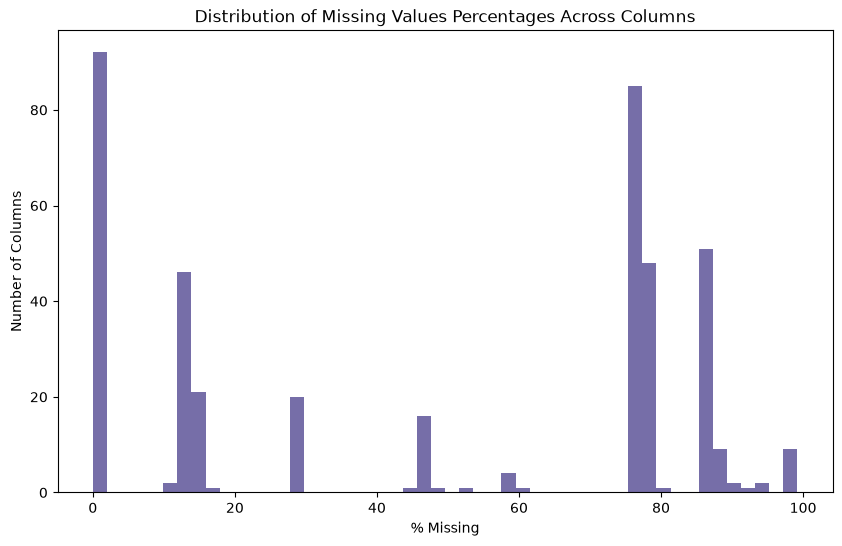

In [15]:
# Visualize Missing Values
missing_percentages = df.isnull().mean() * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.histplot(missing_percentages, bins=50, kde=False, edgecolor='none', color='darkslateblue')
plt.title('Distribution of Missing Values Percentages Across Columns')
plt.xlabel('% Missing')
plt.ylabel('Number of Columns')
plt.savefig('../reports/figures/missing_percentages.png')
plt.show()

#### Visualize Kept vs Dropped Columns

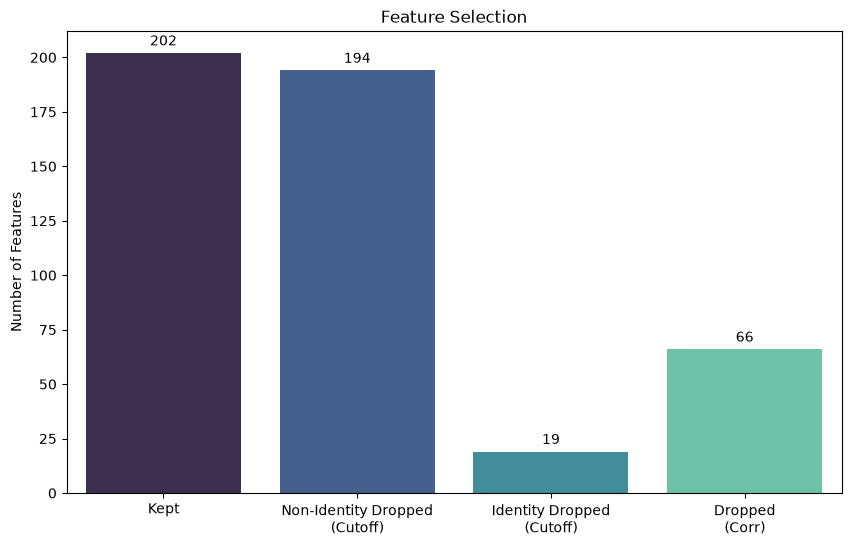

In [16]:
# Visualize Kept vs Dropped Columns
plt.figure(figsize=(10, 6))
categories = ['Kept', 'Non-Identity Dropped\n(Cutoff)', 'Identity Dropped\n(Cutoff)', 'Dropped\n(Corr)']
values = [X_train.shape[1], len(ni_cols_dropped), len(i_cols_dropped), len(correlation_dropped_cols)]
sns.barplot(x=categories, y=values, hue=categories, palette='mako', legend=False)
plt.title('Feature Selection')
plt.ylabel('Number of Features')
for i, v in enumerate(values):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')
plt.savefig('../reports/figures/feature_selection.png')
plt.show()

#### Visualize Correlation Matrix